In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
X, y = joblib.load("features_cache.pkl")

In [17]:
models = ['Random Forest', 'XGBoost', 'CNN']

mae    = [12.06, 12.04, 9.91]
mae_std= [0.83,  0.80,  0.74]
acc1   = [0.426, 0.411, 0.408]
acc1_std=[0.039, 0.033, 0.065]
acc2   = [0.438, 0.422, 0.432]
acc2_std=[0.040, 0.036, 0.054]
  # replace with actual y values from your dataset

cnn_loss = {
    'Fold 1': [21.720, 20.229, 19.646, 18.993],
    'Fold 2': [22.727, 21.533, 20.959, 20.379],
    'Fold 3': [21.013, 19.678, 19.472, 18.686],
    'Fold 4': [23.491, 20.678, 20.486, 19.818],
    'Fold 5': [23.189, 20.753, 21.443, 20.868],
}
epochs = [20, 40, 60, 80]

colors = ['#4878CF', '#6ACC65', '#D65F5F']

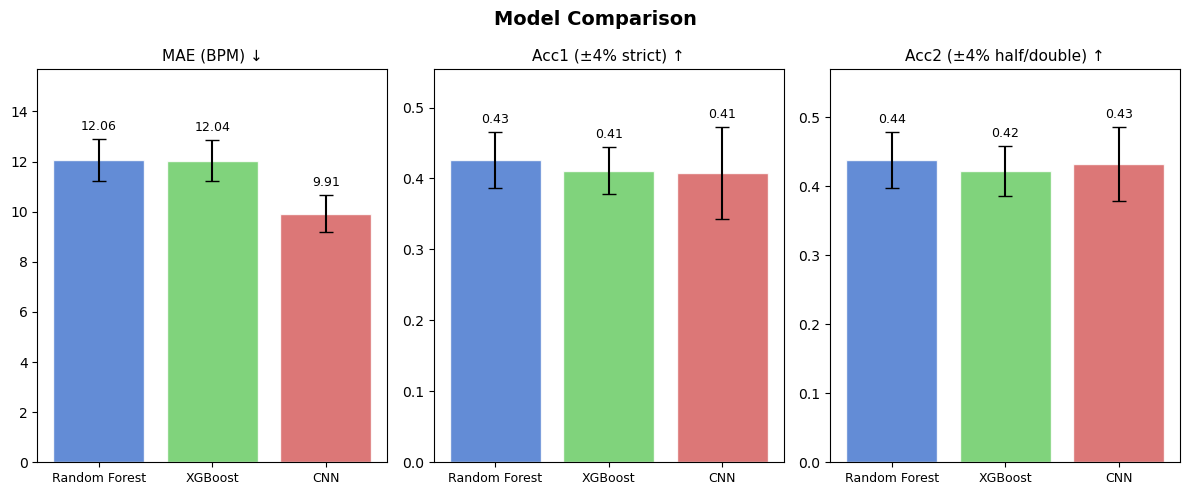

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
fig.suptitle('Model Comparison', fontsize=14, fontweight='bold')

metrics     = [mae,  acc1,  acc2]
stds        = [mae_std, acc1_std, acc2_std]
titles      = ['MAE (BPM) ↓', 'Acc1 (±4% strict) ↑', 'Acc2 (±4% half/double) ↑']

for ax, vals, stds_, title in zip(axes, metrics, stds, titles):
    bars = ax.bar(models, vals, yerr=stds_, capsize=5, color=colors, alpha=0.85, edgecolor='white')
    ax.set_title(title, fontsize=11)
    ax.set_ylim(0, max(vals) * 1.3)
    ax.tick_params(axis='x', labelsize=9)
    for bar, val, std in zip(bars, vals, stds_):
        ax.text(bar.get_x() + bar.get_width()/2, val + std + max(vals)*0.02,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

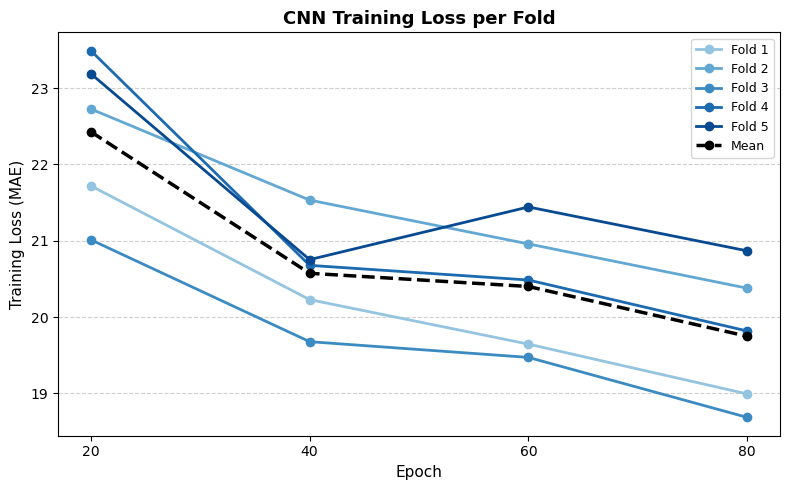

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
fold_colors = plt.cm.Blues(np.linspace(0.4, 0.9, 5))

for (fold_name, losses), c in zip(cnn_loss.items(), fold_colors):
    ax.plot(epochs, losses, marker='o', label=fold_name, color=c, linewidth=2)

mean_losses = np.mean(list(cnn_loss.values()), axis=0)
ax.plot(epochs, mean_losses, marker='o', label='Mean', color='black',
        linewidth=2.5, linestyle='--')

ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Training Loss (MAE)', fontsize=11)
ax.set_title('CNN Training Loss per Fold', fontsize=13, fontweight='bold')
ax.set_xticks(epochs)
ax.legend(fontsize=9)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('cnn_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()


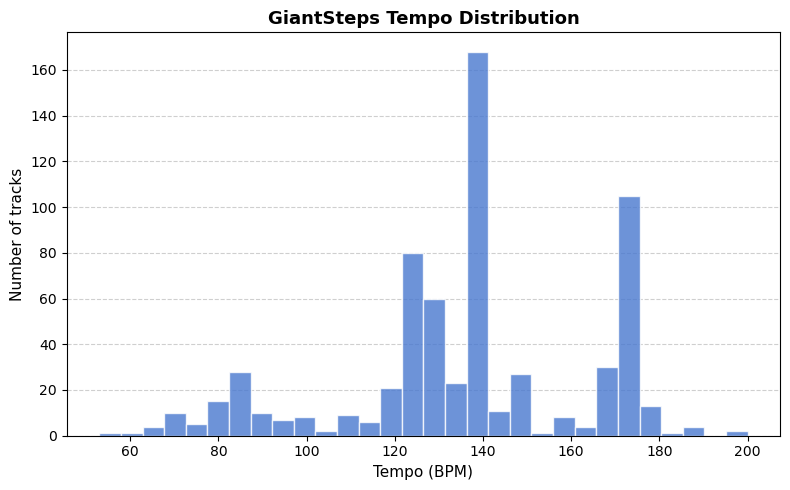

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(y, bins=30, color='#4878CF', alpha=0.8, edgecolor='white')
ax.set_xlabel('Tempo (BPM)', fontsize=11)
ax.set_ylabel('Number of tracks', fontsize=11)
ax.set_title('GiantSteps Tempo Distribution', fontsize=13, fontweight='bold')
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('bpm_distribution.png', dpi=150, bbox_inches='tight')
plt.show()